# Analyse Exploratoire des Données (EDA)

**Objectif :** comprendre le portefeuille client SaaS (10 000 clients), identifier les signaux de churn et quantifier l'enjeu business avant toute modélisation.

**Livrables de ce notebook :**
- Diagnostic qualité des données
- Profil des churners vs clients fidèles
- Hypothèses de features pour le notebook 02
- Estimation du revenu à risque


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

ROOT        = Path('..').resolve()
DATA_PATH   = ROOT / 'data' / 'customer_churn_business_dataset.csv'
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CHURN = 'churn'
RANDOM_STATE = 42

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset introuvable : {DATA_PATH}')

sns.set_theme(style='whitegrid', palette='muted')

df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')
df = df_raw.copy()

print(f'Shape : {df.shape}')
df.head(3)

Shape : (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0


## 1. Qualité des données

In [2]:
print('=== Types & valeurs manquantes ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
display(quality[quality['missing'] > 0])

print(f"Doublons customer_id : {df_raw['customer_id'].duplicated().sum() if 'customer_id' in df_raw.columns else 'N/A'}")
print(f'\nTypes :\n{df.dtypes.value_counts()}')

=== Types & valeurs manquantes ===


,missing,missing_%
complaint_type,2045,20.45


Doublons customer_id : 0

Types :
int64      14
str        12
float64     6
Name: count, dtype: int64


## 2. Variable cible et déséquilibre de classes

churn
0    8979
1    1021
Name: count, dtype: int64

Taux de churn global : 10.2%
→ Dataset déséquilibré : privilégier F1, PR-AUC et le rappel en modélisation.


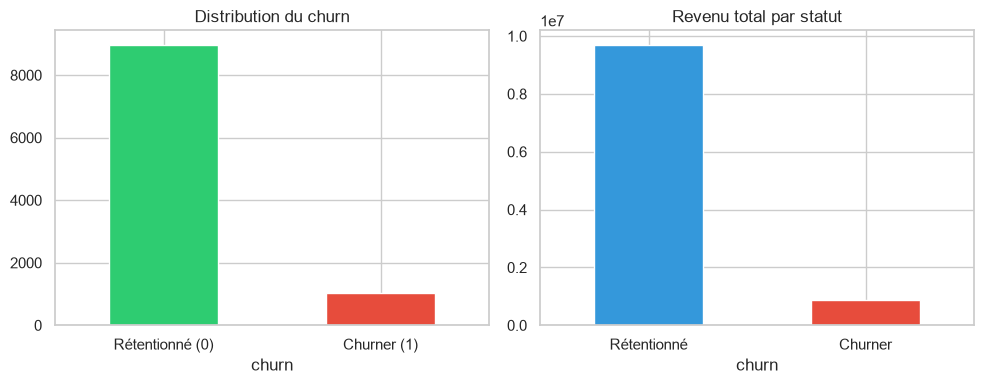

In [3]:
churn_counts = df[TARGET_CHURN].value_counts().sort_index()
churn_rate = df[TARGET_CHURN].mean()
print(churn_counts)
print(f'\nTaux de churn global : {churn_rate:.1%}')
print('→ Dataset déséquilibré : privilégier F1, PR-AUC et le rappel en modélisation.')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution du churn')
axes[0].set_xticklabels(['Rétentionné (0)', 'Churner (1)'], rotation=0)

if 'total_revenue' in df.columns:
    rev_churn = df.groupby(TARGET_CHURN)['total_revenue'].sum()
    rev_churn.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
    axes[1].set_title('Revenu total par statut')
    axes[1].set_xticklabels(['Rétentionné', 'Churner'], rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Statistiques descriptives

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_CHURN in num_cols:
    num_cols.remove(TARGET_CHURN)
if 'customer_id' in num_cols:
    num_cols.remove('customer_id')

desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
display(desc.round(2))

cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'customer_id' in cat_cols:
    cat_cols.remove('customer_id')
print('\nCardinalité des variables catégorielles :')
print(df[cat_cols].nunique().sort_values(ascending=False))

,count,mean,std,min,25%,50%,75%,max,skew
age,10000.0,45.91,16.42,18.00,32.00,46.00,60.00,74.00,0.02
tenure_months,10000.0,30.16,17.10,1.00,16.00,30.00,45.00,59.00,-0.01
monthly_logins,10000.0,19.67,9.84,0.00,13.00,20.00,26.00,54.00,0.14
weekly_active_days,10000.0,3.48,2.30,0.00,1.00,3.00,5.00,7.00,-0.00
avg_session_time,10000.0,15.19,6.83,1.00,10.39,15.16,19.88,42.00,0.10
features_used,10000.0,4.99,2.21,1.00,3.00,5.00,6.00,15.00,0.46
usage_growth_rate,10000.0,0.02,0.15,-0.58,-0.08,0.02,0.12,0.54,-0.01
last_login_days_ago,10000.0,9.51,9.80,0.00,2.00,6.00,13.00,80.00,1.85
monthly_fee,10000.0,34.93,23.79,10.00,20.00,30.00,50.00,100.00,1.12
total_revenue,10000.0,1057.02,1020.15,10.00,340.00,720.00,1440.00,5900.00,1.72



Cardinalité des variables catégorielles :
country                   7
city                      7
customer_segment          3
survey_response           3
signup_channel            3
contract_type             3
payment_method            3
complaint_type            3
gender                    2
price_increase_last_3m    2
discount_applied          2
dtype: int64


## 4. Churn par segment business

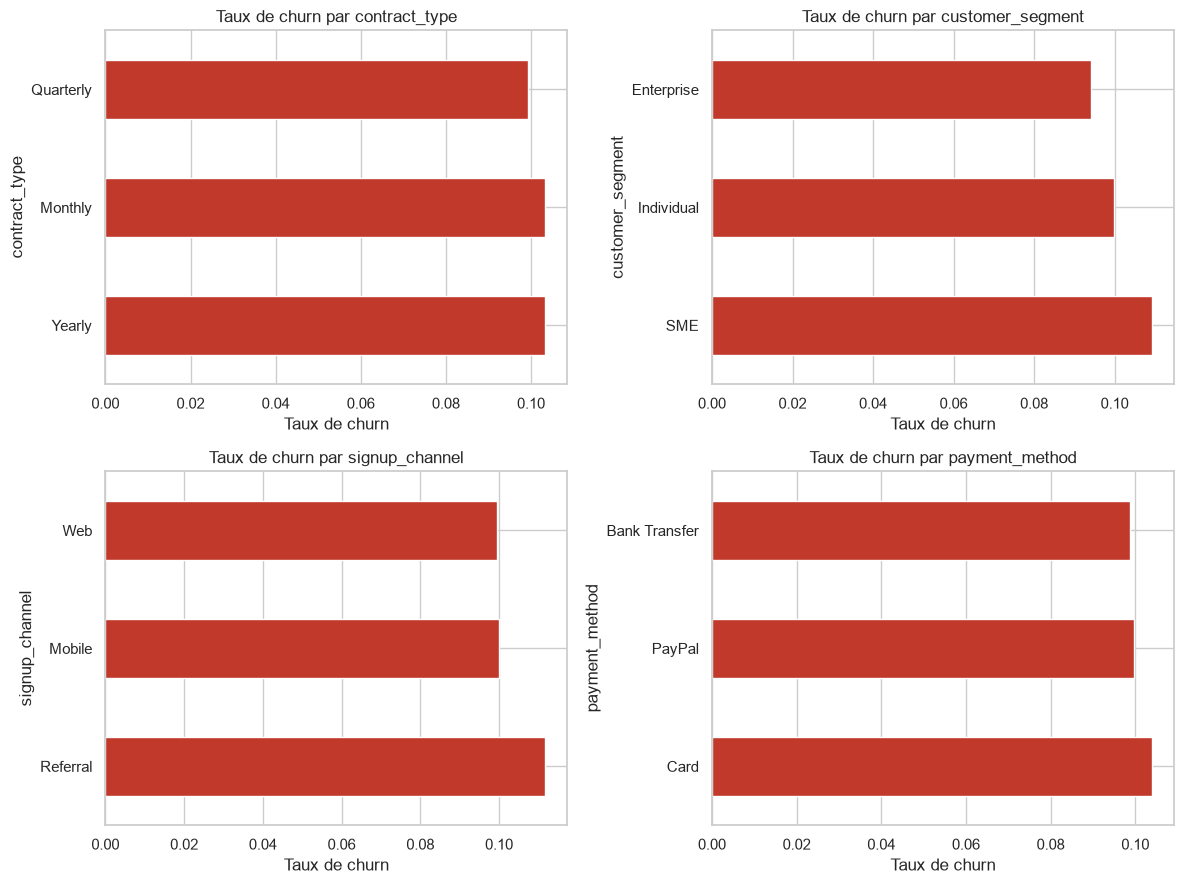

In [5]:
segments = ['contract_type', 'customer_segment', 'signup_channel', 'payment_method']
segments = [c for c in segments if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, col in zip(axes, segments):
    rates = df.groupby(col)[TARGET_CHURN].mean().sort_values(ascending=False)
    rates.plot(kind='barh', ax=ax, color='#c0392b')
    ax.set_title(f'Taux de churn par {col}')
    ax.set_xlabel('Taux de churn')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Comparaison Churners vs Rétentionnés (variables clés)

,Rétentionné,Churner,delta_%
tenure_months,30.83,24.22,-21.4
monthly_logins,20.00,16.80,-16.0
nps_score,19.07,19.46,2.0
csat_score,3.54,3.03,-14.4
payment_failures,0.47,0.74,55.8
support_tickets,1.21,1.21,0.1
monthly_fee,34.97,34.57,-1.1
total_revenue,1081.14,844.90,-21.9
last_login_days_ago,9.38,10.59,12.8
usage_growth_rate,0.02,0.02,13.6


C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CHURN, y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])


C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Rétentionné', 'Churner'])
C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CHURN, y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Rétentionné', 'Churner'])
C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:15: FutureWarning: 

P

C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CHURN, y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Rétentionné', 'Churner'])
C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CHURN, y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
C:\Users\Pret Jeff\AppData\Local\Te

C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_40176\2049040398.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Rétentionné', 'Churner'])


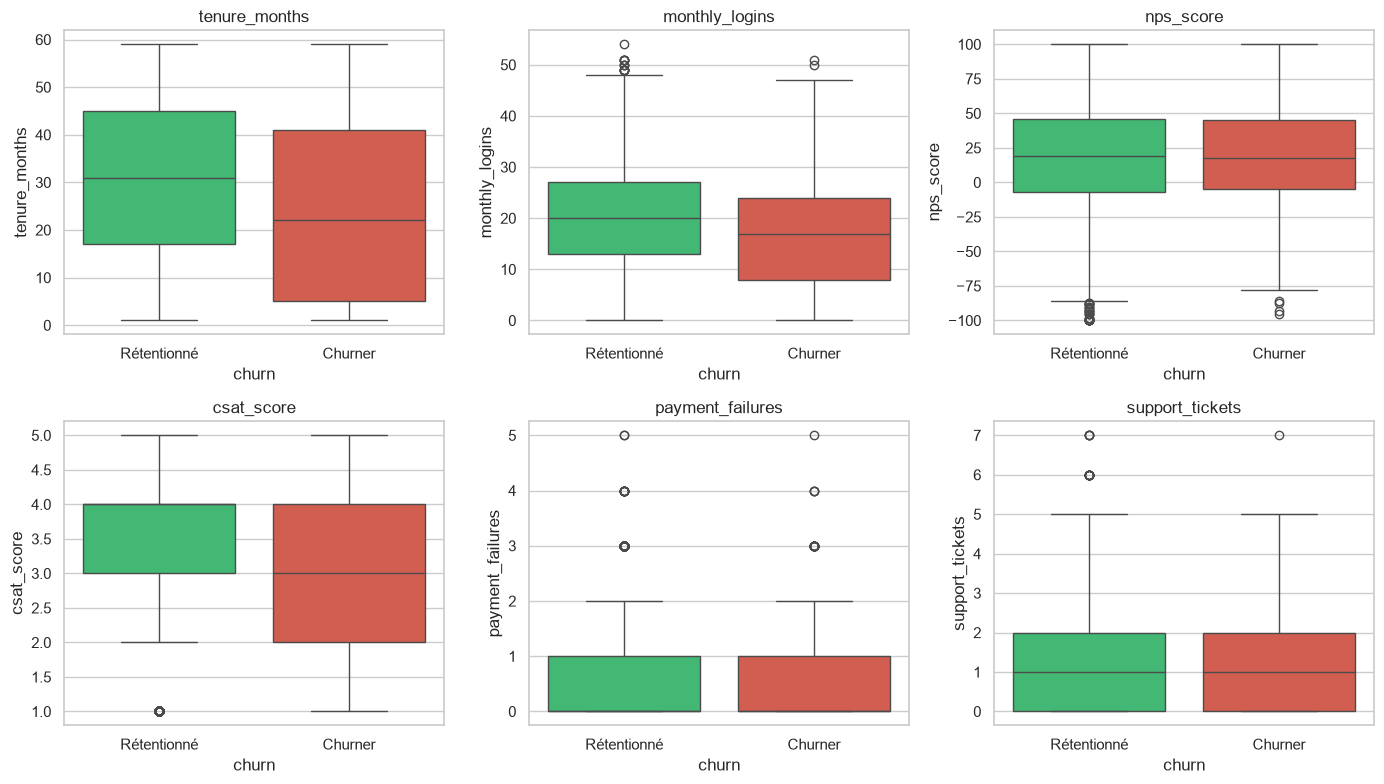

In [6]:
key_numeric = [
    'tenure_months', 'monthly_logins', 'nps_score', 'csat_score',
    'payment_failures', 'support_tickets', 'monthly_fee', 'total_revenue',
    'last_login_days_ago', 'usage_growth_rate',
]
key_numeric = [c for c in key_numeric if c in df.columns]

compare = df.groupby(TARGET_CHURN)[key_numeric].mean().T
compare.columns = ['Rétentionné', 'Churner']
compare['delta_%'] = ((compare['Churner'] - compare['Rétentionné']) / compare['Rétentionné'].replace(0, np.nan) * 100).round(1)
display(compare.round(2))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), key_numeric[:6]):
    sns.boxplot(data=df, x=TARGET_CHURN, y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Rétentionné', 'Churner'])
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_boxplots_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Corrélations & multicolinarité

Top 15 corrélations avec le churn :


,correlation
csat_score,-0.157924
tenure_months,-0.117014
payment_failures,0.112494
monthly_logins,-0.098339
total_revenue,-0.070120
last_login_days_ago,0.037250
email_open_rate,0.011506
age,0.010155
escalations,0.009561
avg_resolution_time,-0.009172


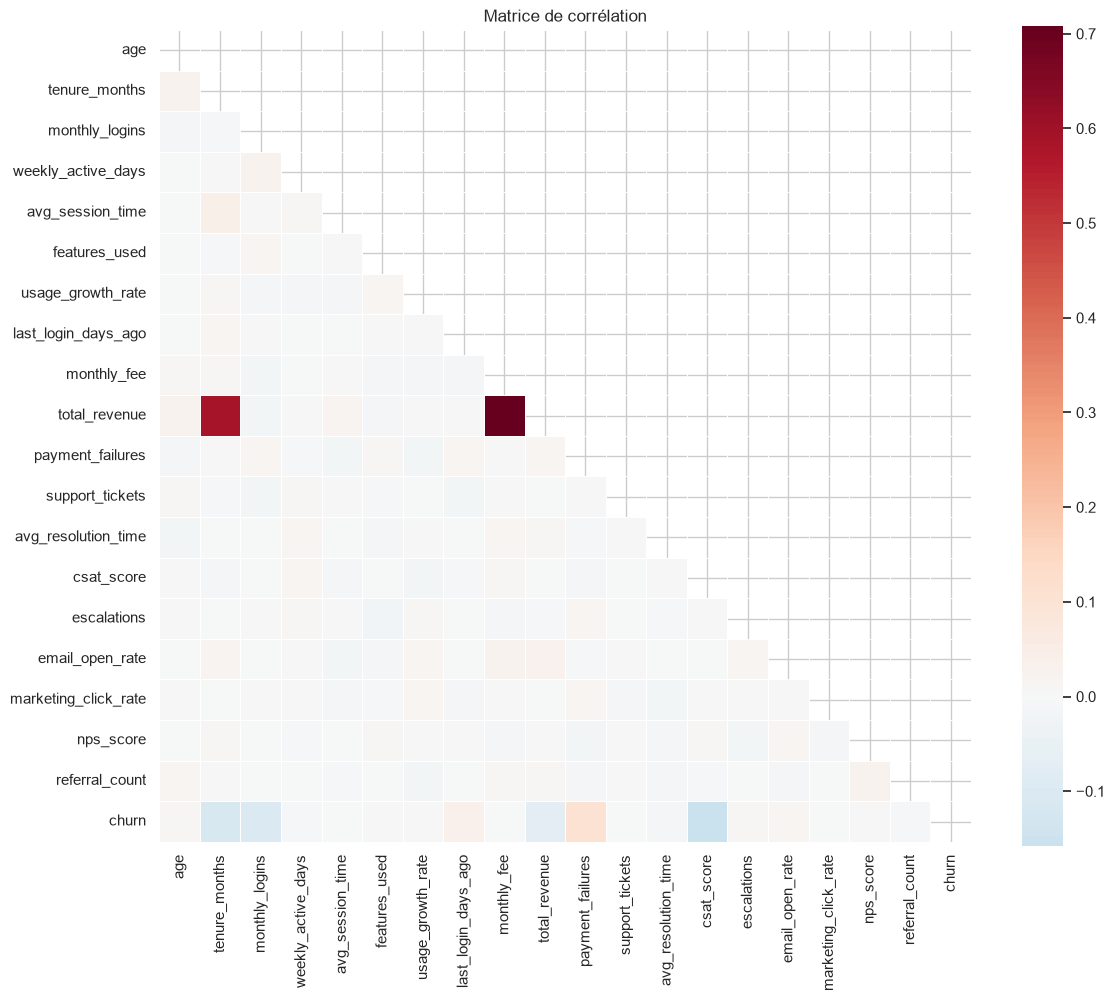

In [7]:
corr = df[num_cols + [TARGET_CHURN]].corr()
target_corr = corr[TARGET_CHURN].drop(TARGET_CHURN).sort_values(key=abs, ascending=False)
print('Top 15 corrélations avec le churn :')
display(target_corr.head(15).to_frame('correlation'))

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Enjeu financier

In [8]:
if 'total_revenue' in df.columns:
    churners = df[df[TARGET_CHURN] == 1]
    rev_at_risk = churners['total_revenue'].sum()
    rev_total = df['total_revenue'].sum()
    print(f'Revenu total portefeuille : {rev_total:,.0f} €')
    print(f'Revenu historique des churners : {rev_at_risk:,.0f} € ({rev_at_risk/rev_total:.1%} du CA)')
    print(f'Revenu moyen par churner : {churners["total_revenue"].mean():,.0f} €')
    if 'monthly_fee' in df.columns:
        print(f'MRR à risque (churners) : {churners["monthly_fee"].sum():,.0f} €/mois')

Revenu total portefeuille : 10,570,180 €
Revenu historique des churners : 862,640 € (8.2% du CA)
Revenu moyen par churner : 845 €
MRR à risque (churners) : 35,300 €/mois


## 8. Synthèse & hypothèses pour la modélisation

| Constat EDA | Action notebook 02 |
|---|---|
| Déséquilibre ~10% churn | `class_weight` / `scale_pos_weight`, métriques F1 & PR-AUC |
| `complaint_type` manquant (~20%) | Imputation `'Unknown'` dans le pipeline |
| Signaux engagement (logins, NPS, CSAT) | Feature `engagement_score` composite |
| Tickets & paiements corrélés au churn | `tickets_per_tenure`, `fee_per_tenure` |
| Risque de fuite si scaler avant split | Split **avant** fit du preprocessor |
